In [48]:
!pip install vaderSentiment NRCLex demoji -qqq

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import demoji
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression,Ridge,Lasso,LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix,classification_report
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nrclex import NRCLex

In [50]:
df=pd.read_csv('/content/drive/MyDrive/YT_Videos_Comments_100k.csv')
df=df[['Comment (Actual)','Comment Author','Video Title']]
df.columns=['comment','author','video']
print(df.shape)
df.head()

(99981, 3)


,comment,author,video
0,"This is way less cool than it seems, spiders a...",CMZ neu,"Robots made of spiders (yes, really)"
1,Spiders see this and this is why they made the...,Kiana Marrie,"Robots made of spiders (yes, really)"
2,you looks pretty 😍,Noob,"Robots made of spiders (yes, really)"
3,arcade machines in australia be like,Hardik B,"Robots made of spiders (yes, really)"
4,Wake up babe new horrific state of consciousne...,hufta,"Robots made of spiders (yes, really)"


In [51]:
print(df.shape)
df.info()
df.isnull().sum()

(99981, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99981 entries, 0 to 99980
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  99863 non-null  object
 1   author   99838 non-null  object
 2   video    99942 non-null  object
dtypes: object(3)
memory usage: 2.3+ MB


,0
comment,118
author,143
video,39


In [ ]:
print("--- Data Statistics ---")
print(f"Total Unique Videos: {df['video'].nunique()}")
print(f"Total Unique Authors: {df['author'].nunique()}")
display(df['video'].value_counts().head(10))

In [52]:
df = df.dropna(subset=['comment']).reset_index(drop=True)
def clean_txt(t):
    t=str(t).lower()
    t=re.sub(r'http\S+|www\S+','',t)
    t=re.sub(r'\s+',' ',t).strip()
    return t
df['clean']=df['comment'].apply(clean_txt)
df=df[df['clean'].str.len() > 3].reset_index(drop=True)
print(df.shape)
df[['comment','clean']].head()

(98876, 4)


,comment,clean
0,"This is way less cool than it seems, spiders a...","this is way less cool than it seems, spiders a..."
1,Spiders see this and this is why they made the...,spiders see this and this is why they made the...
2,you looks pretty 😍,you looks pretty 😍
3,arcade machines in australia be like,arcade machines in australia be like
4,Wake up babe new horrific state of consciousne...,wake up babe new horrific state of consciousne...


In [53]:
an=SentimentIntensityAnalyzer()
def get_score(t):
    s=an.polarity_scores(str(t))['compound']
    return round((s+1)*50,2)
df['sentiment_score']=df['comment'].apply(get_score)
df['sentiment_score'].describe()

,sentiment_score
count,98876.000000
mean,60.672384
std,22.477266
min,0.060000
25%,50.000000
50%,55.130000
75%,79.970000
max,100.000000


In [54]:
emo=['joy','trust','anticipation','surprise','fear','sadness','anger']
def get_emo(t):
    try:
        x=NRCLex(str(t))
        d={k:v for k,v in x.raw_emotion_scores.items() if k in emo}
        if len(d)>0:
            return max(d,key=d.get)
    except:
        pass
    s=an.polarity_scores(str(t))['compound']
    if s>=0.6: return 'joy'
    elif s>=0.3: return 'trust'
    elif s>=0.05: return 'anticipation'
    elif s>-0.05: return 'surprise'
    elif s>-0.3: return 'fear'
    elif s>-0.6: return 'sadness'
    else: return 'anger'
df['mood']=df['comment'].apply(get_emo)
display(df['mood'].value_counts())

,count
mood,
surprise,29451
joy,24693
trust,19005
sadness,8103
anticipation,7077
fear,5948
anger,4599


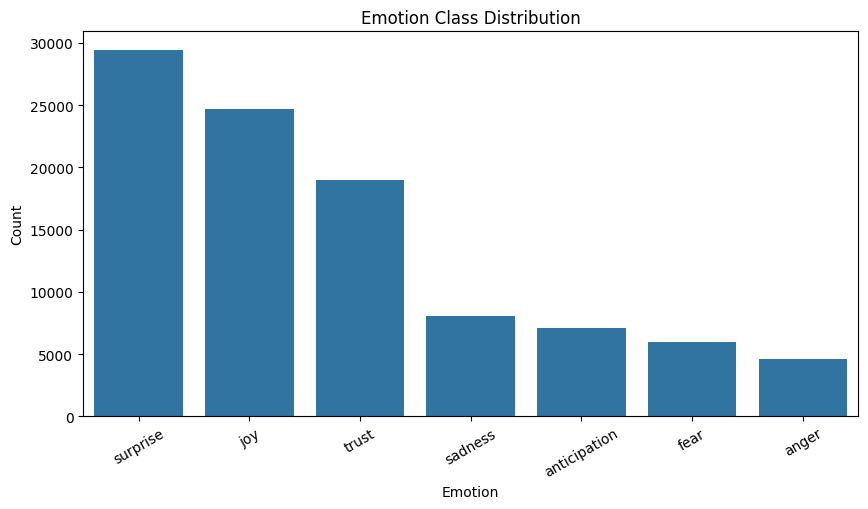

In [55]:
plt.figure(figsize=(10,5))
sns.countplot(x='mood',data=df,order=df['mood'].value_counts().index)
plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

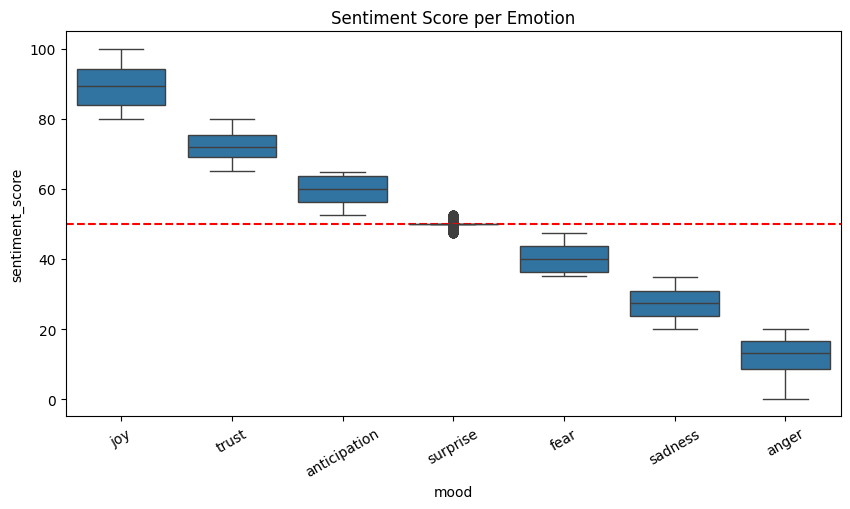

In [56]:
plt.figure(figsize=(10,5))
sns.boxplot(x='mood',y='sentiment_score',data=df,order=df.groupby('mood')['sentiment_score'].median().sort_values(ascending=False).index)
plt.axhline(50,color='red',linestyle='--')
plt.title("Sentiment Score per Emotion")
plt.xticks(rotation=30)
plt.show()

In [57]:
tf=TfidfVectorizer(max_features=2000,ngram_range=(1,2),stop_words='english',min_df=5,max_df=0.90)
X=tf.fit_transform(df['clean'])
print(X.shape)

(98876, 2000)


In [58]:
y=df['sentiment_score']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)
print("Train :",X_train.shape)
print("Test  :",X_test.shape)

Train : (79100, 2000)
Test  : (19776, 2000)


In [59]:
models={
    'Linear Regression':LinearRegression(),
    'Ridge':Ridge(alpha=1.0),
    'Lasso':Lasso(alpha=0.001)
    }
res=[]
prd={}
for n,m in models.items():
    m.fit(X_train,y_train)
    p=m.predict(X_test)
    prd[n]=p
    mse=mean_squared_error(y_test,p)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,p)
    mae=np.mean(np.abs(y_test-p))
    res.append([n,mae,mse,rmse,r2])
reg_df=pd.DataFrame(res,columns=['Model','MAE','MSE','RMSE','R2'])
reg_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,10.900691,239.364008,15.471393,0.528268
1,Ridge,10.892976,238.707223,15.450153,0.529562
2,Lasso,10.804810,237.504366,15.411177,0.531932


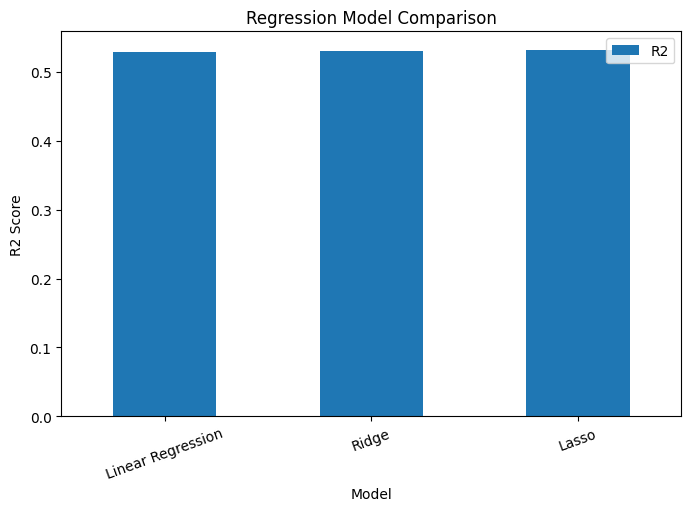

In [60]:
reg_df.plot(x='Model',y='R2',kind='bar',figsize=(8,5))
plt.title("Regression Model Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

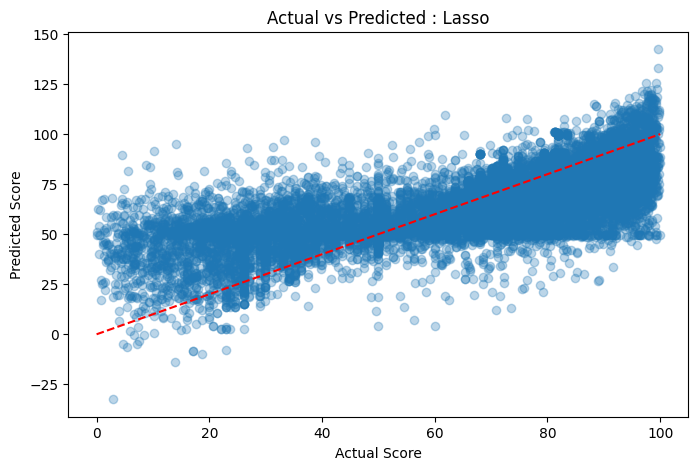

Best Model : Lasso


In [61]:
best=reg_df.sort_values('R2',ascending=False).iloc[0,0]
p=prd[best]
plt.figure(figsize=(8,5))
plt.scatter(y_test,p,alpha=0.3)
plt.plot([0,100],[0,100],'r--')
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted : "+best)
plt.show()
print("Best Model :",best)

In [62]:
le=LabelEncoder()
y2=le.fit_transform(df['mood'])
X_train2,X_test2,y_train2,y_test2=train_test_split(X,y2,test_size=0.2,random_state=0)
print("Classes:",list(le.classes_))
print("Train:",X_train2.shape)
print("Test:",X_test2.shape)

Classes: ['anger', 'anticipation', 'fear', 'joy', 'sadness', 'surprise', 'trust']
Train: (79100, 2000)
Test: (19776, 2000)


In [63]:
models2={
    'Logistic L2':LogisticRegression(penalty='l2',max_iter=500,solver='saga',n_jobs=-1),
    'Logistic L1':LogisticRegression(penalty='l1',solver='liblinear',max_iter=500),
    'Random Forest':RandomForestClassifier(n_estimators=50,class_weight='balanced',n_jobs=-1)
}
res2=[]
for n,m in models2.items():
    m.fit(X_train2,y_train2)
    p=m.predict(X_test2)
    pre=precision_score(y_test2,p,average='weighted')
    rec=recall_score(y_test2,p,average='weighted')
    f1=f1_score(y_test2,p,average='weighted')
    res2.append([n,pre,rec,f1])
cls_df=pd.DataFrame(res2,columns=['Model','Precision','Recall','F1'])
display(cls_df)

,Model,Precision,Recall,F1
0,Logistic L2,0.579699,0.616303,0.579285
1,Logistic L1,0.576580,0.614331,0.575331
2,Random Forest,0.577511,0.607453,0.581437


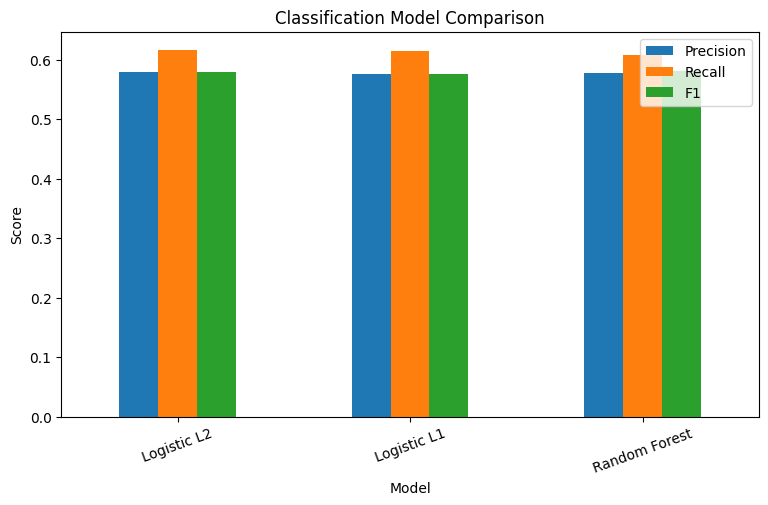

In [64]:
cls_df.plot(x='Model',y=['Precision','Recall','F1'],kind='bar',figsize=(9,5))
plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

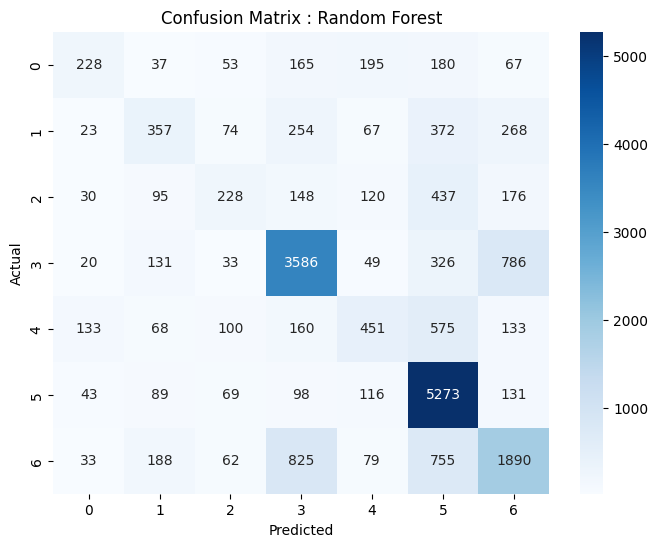

Best Classification Model : Random Forest

              precision    recall  f1-score   support

       anger       0.45      0.25      0.32       925
anticipation       0.37      0.25      0.30      1415
        fear       0.37      0.18      0.25      1234
         joy       0.68      0.73      0.71      4931
     sadness       0.42      0.28      0.33      1620
    surprise       0.67      0.91      0.77      5819
       trust       0.55      0.49      0.52      3832

    accuracy                           0.61     19776
   macro avg       0.50      0.44      0.46     19776
weighted avg       0.58      0.61      0.58     19776



In [65]:
best2=cls_df.sort_values('F1',ascending=False).iloc[0,0]
mdl=models2[best2]
pred=mdl.predict(X_test2)
cm=confusion_matrix(y_test2,pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix : "+best2)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("Best Classification Model :",best2)
print()
print(classification_report(y_test2,pred,target_names=le.classes_))

In [66]:
df['actual_score']=df['sentiment_score']
df['actual_mood']=df['mood']
df['predicted_score']=models[best].predict(X)
df['predicted_mood']=le.inverse_transform(models2[best2].predict(X))
df['score_diff']=abs(df['actual_score']-df['predicted_score'])
df['mood_match']=np.where(df['actual_mood']==df['predicted_mood'],'Yes','No')
out=df[['comment','clean','author','video','actual_score','predicted_score','score_diff','actual_mood','predicted_mood','mood_match']]
out.to_csv('youtube_comment_analysis_output.csv',index=False)
print("CSV File Saved Successfully")
out.head()

CSV File Saved Successfully


,comment,clean,author,video,actual_score,predicted_score,score_diff,actual_mood,predicted_mood,mood_match
0,"This is way less cool than it seems, spiders a...","this is way less cool than it seems, spiders a...",CMZ neu,"Robots made of spiders (yes, really)",7.43,26.239481,18.809481,anger,anger,Yes
1,Spiders see this and this is why they made the...,spiders see this and this is why they made the...,Kiana Marrie,"Robots made of spiders (yes, really)",12.97,49.364746,36.394746,anger,surprise,No
2,you looks pretty 😍,you looks pretty 😍,Noob,"Robots made of spiders (yes, really)",86.76,80.064098,6.695902,joy,joy,Yes
3,arcade machines in australia be like,arcade machines in australia be like,Hardik B,"Robots made of spiders (yes, really)",68.06,65.711382,2.348618,trust,trust,Yes
4,Wake up babe new horrific state of consciousne...,wake up babe new horrific state of consciousne...,hufta,"Robots made of spiders (yes, really)",17.02,50.163740,33.143740,anger,anger,Yes


In [69]:
from google.colab import files
files.download('youtube_comment_analysis_output.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>